In [2]:
import warnings


warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pm4py
from pm4py.objects.conversion.log import converter as log_converter


DATASET_LIST = [
    'BPIC_12',
    'BPIC_12_A',
    'BPIC_12_O',
    'BPIC_12_W',
    'BPIC_13_C',
    'BPIC_13_I',
    'BPIC_15_1',
    'BPIC_15_2',
    'BPIC_15_3',
    'BPIC_15_4',
    'BPIC_15_5',
    'BPIC_18_C',
    'BPIC_18_G',
    'BPIC_18_P',
    'BPIC_20_DD',
    'BPIC_20_ID',
    'BPIC_20_PTC',
    'BPIC_20_RFP',
    'BPIC_20_TPD',
    'Helpdesk',
    'Hospital_Billing',
    'Traffic_Fines',
    'Sepsis',
]

DATASET_FOLDER = Path('C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/raw')


EVENT_NAME_COLS = {
    'BPIC_15_1': 'activityNameEN',
    'BPIC_15_2': 'activityNameEN',
    'BPIC_15_3': 'activityNameEN',
    'BPIC_15_4': 'activityNameEN',
    'BPIC_15_5': 'activityNameEN',
}


END_EVENTS = {
    'BPIC_20_DD': ['Payment Handled'],
    'BPIC_20_ID': ['Payment Handled'],
    'BPIC_20_PTC': ['Payment Handled'],
    'BPIC_20_RFP': ['Payment Handled'],
    'BPIC_20_TPD': ['Payment Handled'],
    'Helpdesk': ['Closed'],
    'Hospital_Billing': ['BILLED', 'NEW'],
    'Traffic_Fines': ['Payment', 'Send for Credit Collection', 'Send Fine'],
}

In [3]:
def load_log(dataset_name: str):
    path = DATASET_FOLDER / f'{dataset_name}.xes'

    log_df = pm4py.read_xes(str(path))
    log = log_converter.apply(log_df)
    return log, log_df


def get_events_number(log_df: pd.DataFrame):
    return log_df.shape[0]


def get_cases_number(log_df: pd.DataFrame):
    return log_df['case:concept:name'].nunique()


def get_unique_events(log_df: pd.DataFrame, event_col: str = 'concept:name'):
    return sorted(log_df[event_col].unique())


def get_trace_length(log_df: pd.DataFrame):
    trace_lengths = log_df.groupby('case:concept:name').size()
    return trace_lengths.tolist()


def get_trace_duration(log_df: pd.DataFrame):
    log_df = log_df.sort_values(by=['time:timestamp'])
    trace_durations = log_df.groupby('case:concept:name')['time:timestamp'].agg(
        ['min', 'max']
    )
    trace_durations['duration'] = (
        trace_durations['max'] - trace_durations['min']
    ).dt.total_seconds() / (24 * 60 * 60)
    return trace_durations['duration'].tolist()


def get_start_events(log_df: pd.DataFrame, event_col: str = 'concept:name'):
    log_df = log_df.sort_values(by=['time:timestamp'])
    start_events = log_df.groupby('case:concept:name').first()[event_col]
    return start_events.value_counts().to_dict()


def get_end_events(log_df: pd.DataFrame, event_col: str = 'concept:name'):
    log_df = log_df.sort_values(by=['time:timestamp'])
    end_events = log_df.groupby('case:concept:name').last()[event_col]
    return end_events.value_counts().to_dict()

## Dataset Analysis

In [4]:
def get_trace_length_distribution(log_df: pd.DataFrame, dataset_name: str):
    lengths = get_trace_length(log_df)

    plt.figure(figsize=(10, 6))
    plt.hist(
        lengths,
        bins=range(min(lengths), max(lengths) + 2),
        color='skyblue',
        edgecolor='black',
        alpha=0.7,
    )

    percentiles = [
        {
            'label': '80% Percentile',
            'value': np.percentile(lengths, 80),
            'color': 'red',
            'linestyle': 'dashed',
        },
        {
            'label': '90% Percentile',
            'value': np.percentile(lengths, 90),
            'color': 'orange',
            'linestyle': 'dashed',
        },
        {
            'label': '95% Percentile',
            'value': np.percentile(lengths, 95),
            'color': 'purple',
            'linestyle': 'dashed',
        },
        {
            'label': 'Median',
            'value': np.median(lengths),
            'color': 'green',
            'linestyle': 'dotted',
        },
    ]

    for p in percentiles:
        plt.axvline(
            p['value'],
            color=p['color'],
            linestyle=p['linestyle'],
            linewidth=2,
            label=f'{p["label"]} ({int(p["value"])})',
        )

    plt.title(f'Trace Length Distribution: {dataset_name}')
    plt.xlabel('Number of Events (Trace Length)')
    plt.ylabel('Frequency (Number of Traces)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()


def get_trace_duration_distribution(log_df: pd.DataFrame, dataset_name: str):
    durations = get_trace_duration(log_df)

    plt.figure(figsize=(10, 6))
    plt.hist(
        durations,
        bins=10,
        color='lightcoral',
        edgecolor='black',
        alpha=0.7,
    )

    percentiles = [
        {
            'label': '80% Percentile',
            'value': np.percentile(durations, 80),
            'color': 'red',
            'linestyle': 'dashed',
        },
        {
            'label': '90% Percentile',
            'value': np.percentile(durations, 90),
            'color': 'orange',
            'linestyle': 'dashed',
        },
        {
            'label': '95% Percentile',
            'value': np.percentile(durations, 95),
            'color': 'purple',
            'linestyle': 'dashed',
        },
        {
            'label': 'Median',
            'value': np.median(durations),
            'color': 'green',
            'linestyle': 'dotted',
        },
    ]

    for p in percentiles:
        plt.axvline(
            p['value'],
            color=p['color'],
            linestyle=p['linestyle'],
            linewidth=2,
            label=f'{p["label"]} ({int(p["value"]):,} days)',
        )

    plt.title(f'Trace Duration Distribution: {dataset_name}')
    plt.xlabel('Duration (Days)')
    plt.ylabel('Frequency (Number of Traces)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()


def get_class_balance(log_df: pd.DataFrame, dataset_name: str):

    # Drop first event per trace (never used as target)
    log_df = log_df.sort_values(by=['time:timestamp'])
    first_event_indices = log_df.groupby('case:concept:name').head(1).index
    filtered_df = log_df.drop(first_event_indices)

    class_counts = filtered_df['concept:name'].value_counts()

    plt.figure(figsize=(12, 6))
    class_counts.plot(kind='barh', color='steelblue')
    plt.xlabel('Frequency')
    plt.ylabel('Event')
    plt.title(f'Class Balance: {dataset_name}')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [165]:
for dataset_name in DATASET_LIST:
    log, log_df = load_log(dataset_name)

    event_col = EVENT_NAME_COLS.get(dataset_name, 'concept:name')

    unique_events = get_unique_events(log_df, event_col)

    print(f'Dataset: {dataset_name}')
    print(f'Number of unique events: {len(unique_events)}')
    print(f'Unique events: {unique_events}')
    print(f'End events: {get_end_events(log_df, event_col)}')
    print(f'Number of events: {len(log_df)}')
    print(f'Number of traces: {log_df["case:concept:name"].nunique()}')
    print('================================')

parsing log, completed traces :: 100%|██████████| 13087/13087 [00:06<00:00, 1940.24it/s]


Dataset: BPIC_12
Number of unique events: 24
Unique events: ['A_ACCEPTED', 'A_ACTIVATED', 'A_APPROVED', 'A_CANCELLED', 'A_DECLINED', 'A_FINALIZED', 'A_PARTLYSUBMITTED', 'A_PREACCEPTED', 'A_REGISTERED', 'A_SUBMITTED', 'O_ACCEPTED', 'O_CANCELLED', 'O_CREATED', 'O_DECLINED', 'O_SELECTED', 'O_SENT', 'O_SENT_BACK', 'W_Afhandelen leads', 'W_Beoordelen fraude', 'W_Completeren aanvraag', 'W_Nabellen incomplete dossiers', 'W_Nabellen offertes', 'W_Valideren aanvraag', 'W_Wijzigen contractgegevens']
End events: {'A_DECLINED': 3429, 'W_Valideren aanvraag': 2747, 'W_Afhandelen leads': 2234, 'W_Completeren aanvraag': 1940, 'W_Nabellen offertes': 1291, 'A_CANCELLED': 653, 'W_Nabellen incomplete dossiers': 452, 'O_CANCELLED': 279, 'W_Beoordelen fraude': 57, 'W_Wijzigen contractgegevens': 4, 'A_APPROVED': 1}
Number of events: 262200
Number of traces: 13087


parsing log, completed traces :: 100%|██████████| 13087/13087 [00:01<00:00, 9180.03it/s]


Dataset: BPIC_12_A
Number of unique events: 10
Unique events: ['A_ACCEPTED', 'A_ACTIVATED', 'A_APPROVED', 'A_CANCELLED', 'A_DECLINED', 'A_FINALIZED', 'A_PARTLYSUBMITTED', 'A_PREACCEPTED', 'A_REGISTERED', 'A_SUBMITTED']
End events: {'A_DECLINED': 7635, 'A_CANCELLED': 2807, 'A_ACTIVATED': 986, 'A_REGISTERED': 816, 'A_APPROVED': 444, 'A_FINALIZED': 327, 'A_PREACCEPTED': 69, 'A_ACCEPTED': 3}
Number of events: 60849
Number of traces: 13087


parsing log, completed traces :: 100%|██████████| 5015/5015 [00:00<00:00, 5234.40it/s]


...

Dataset: Hospital_Billing
Number of unique events: 18
Unique events: ['BILLED', 'CHANGE DIAGN', 'CHANGE END', 'CODE ERROR', 'CODE NOK', 'CODE OK', 'DELETE', 'EMPTY', 'FIN', 'JOIN-PAT', 'MANUAL', 'NEW', 'REJECT', 'RELEASE', 'REOPEN', 'SET STATUS', 'STORNO', 'ZDBC_BEHAN']
End events: {'BILLED': 63498, 'NEW': 22407, 'DELETE': 8215, 'FIN': 3611, 'CODE OK': 948, 'SET STATUS': 600, 'EMPTY': 444, 'RELEASE': 107, 'MANUAL': 85, 'JOIN-PAT': 47, 'CHANGE DIAGN': 19, 'CODE NOK': 14, 'REJECT': 4, 'STORNO': 1}
Number of events: 451359
Number of traces: 100000


parsing log, completed traces :: 100%|██████████| 1050/1050 [00:00<00:00, 2642.33it/s]


Dataset: Sepsis
Number of unique events: 16
Unique events: ['Admission IC', 'Admission NC', 'CRP', 'ER Registration', 'ER Sepsis Triage', 'ER Triage', 'IV Antibiotics', 'IV Liquid', 'LacticAcid', 'Leucocytes', 'Release A', 'Release B', 'Release C', 'Release D', 'Release E', 'Return ER']
End events: {'Release A': 393, 'Return ER': 291, 'IV Antibiotics': 87, 'Release B': 55, 'ER Sepsis Triage': 49, 'Leucocytes': 49, 'CRP': 48, 'Release C': 19, 'Admission NC': 14, 'Release D': 14, 'LacticAcid': 12, 'IV Liquid': 12, 'Release E': 5, 'ER Triage': 2}
Number of events: 15214
Number of traces: 1050


parsing log, completed traces :: 100%|██████████| 150370/150370 [00:17<00:00, 8762.64it/s] 


Dataset: Traffic_Fines
Number of unique events: 11
Unique events: ['Add penalty', 'Appeal to Judge', 'Create Fine', 'Insert Date Appeal to Prefecture', 'Insert Fine Notification', 'Notify Result Appeal to Offender', 'Payment', 'Receive Result Appeal from Prefecture', 'Send Appeal to Prefecture', 'Send Fine', 'Send for Credit Collection']
End events: {'Payment': 64400, 'Send for Credit Collection': 58997, 'Send Fine': 20682, 'Send Appeal to Prefecture': 3103, 'Create Fine': 2470, 'Add penalty': 449, 'Appeal to Judge': 127, 'Notify Result Appeal to Offender': 88, 'Receive Result Appeal from Prefecture': 54}
Number of events: 561470
Number of traces: 150370


In [6]:
log, log_df = load_log('BPIC_15_1')

event_col = EVENT_NAME_COLS.get('BPIC_15_1', 'concept:name')

unique_events = get_unique_events(log_df, event_col)

print(len(unique_events))

parsing log, completed traces :: 100%|██████████| 1199/1199 [00:02<00:00, 421.89it/s]


289


parsing log, completed traces :: 100%|██████████| 1199/1199 [00:02<00:00, 465.97it/s]


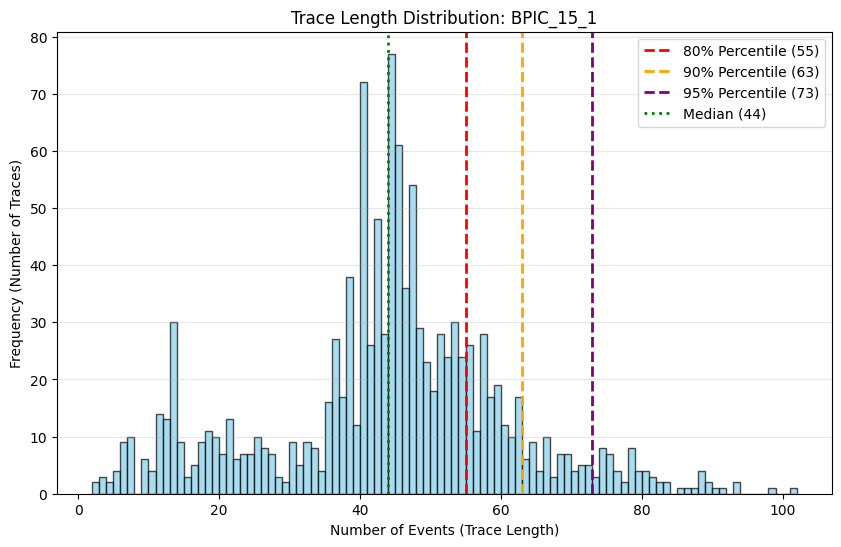

In [11]:
dataset_name = 'BPIC_20_DD'
dataset_name = 'BPIC_15_1'

log, log_df = load_log(dataset_name)

get_trace_length_distribution(log_df, dataset_name)

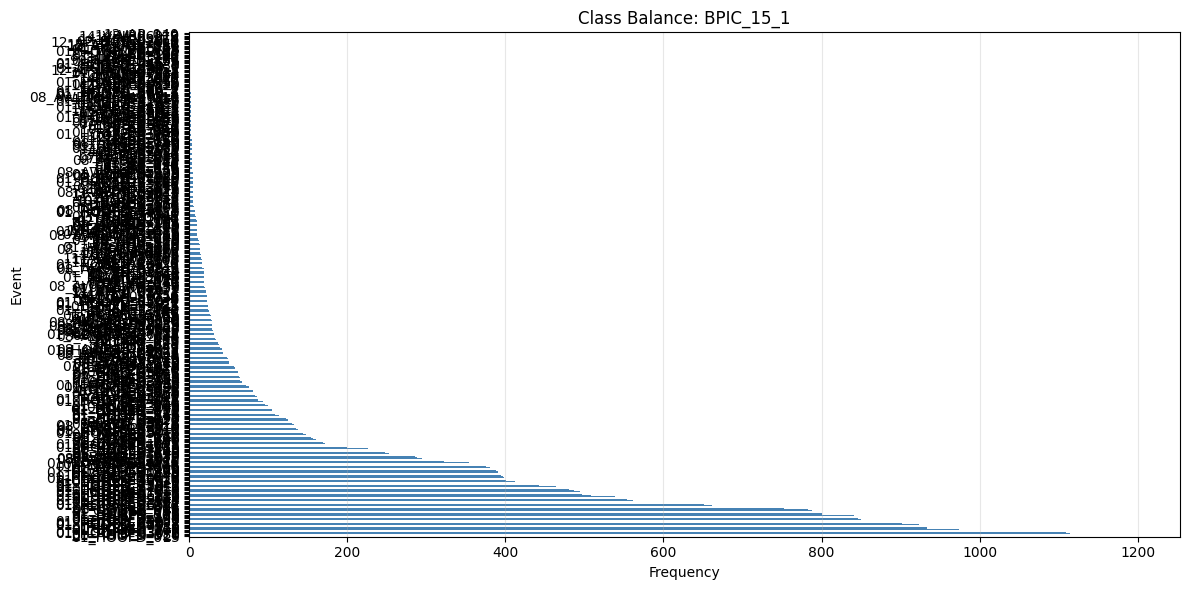

In [12]:
get_class_balance(log_df, dataset_name)

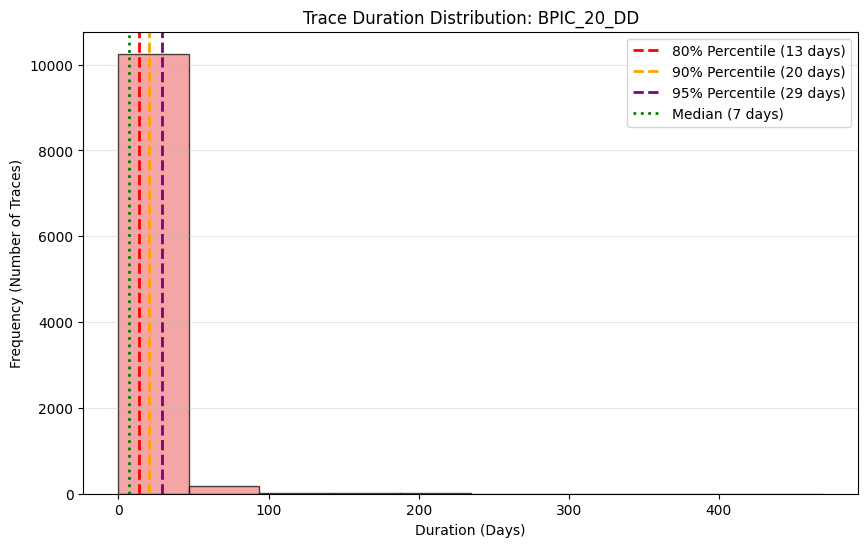

In [6]:
get_trace_duration_distribution(log_df, dataset_name)

In [139]:
unique_events = get_unique_events(log_df)
events_number = get_events_number(log_df)
cases_number = get_cases_number(log_df)
preds_number = events_number - cases_number

print(f'Number of Unique Events: {len(unique_events)}')
print(f'Unique Events: {unique_events}')

print(f'Number of Events: {events_number}')
print(f'Number of Cases: {cases_number}')
print(f'Number of Predictions: {preds_number}')

print(f'Start events: {get_start_events(log_df)}')
print(f'End events: {get_end_events(log_df)}')

Number of Unique Events: 4
Unique Events: ['Accepted', 'Completed', 'Queued', 'Unmatched']
Number of Events: 65533
Number of Cases: 7554
Number of Predictions: 57979
Start events: {'Accepted': 6394, 'Queued': 1156, 'Completed': 4}
End events: {'Completed': 7546, 'Accepted': 8}


In [143]:
def sample_complete_traces_and_save_xes(
    log_df: pd.DataFrame,
    output_path: str,
    fraction: float | None = None,
    n_cases: int | None = None,
    random_state: int = 42,
):
    case_col = 'case:concept:name'
    time_col = 'time:timestamp'

    if (fraction is None) == (n_cases is None):
        raise ValueError('Set exactly one of: fraction or n_cases.')

    case_ids = log_df[case_col].dropna().unique()
    total_cases = len(case_ids)

    if fraction is not None:
        if not (0 < fraction <= 1):
            raise ValueError('fraction must be in (0, 1].')
        k = max(1, int(round(total_cases * fraction)))
    else:
        if n_cases <= 0:
            raise ValueError('n_cases must be > 0.')
        k = min(n_cases, total_cases)

    rng = np.random.default_rng(random_state)
    sampled_case_ids = rng.choice(case_ids, size=k, replace=False)

    # keep full traces (all events for selected cases)
    sampled_df = log_df[log_df[case_col].isin(sampled_case_ids)].copy()

    # stable ordering (recommended before export)
    sort_cols = [case_col] + ([time_col] if time_col in sampled_df.columns else [])
    sampled_df = sampled_df.sort_values(sort_cols)

    # DataFrame -> EventLog -> XES
    sampled_log = log_converter.apply(sampled_df)
    pm4py.write_xes(sampled_log, output_path)

    print(f'Saved: {output_path}')
    print(f'Cases: {k}/{total_cases}')
    print(f'Events: {len(sampled_df)}')

    return sampled_df

## DARWIN

### Next activity

In [4]:
def get_stream_size(
    log_df: pd.DataFrame,
    max_events_rate: float = 0.1,
    init_size_rate: float = 0.8,
    case_id_col: str = 'case:concept:name',
    time_col: str = 'time:timestamp',
):
    log_df = log_df.sort_values(time_col).reset_index(drop=True)
    total_events = len(log_df)
    total_cases = log_df[case_id_col].nunique()

    max_events = math.ceil(total_events * max_events_rate)

    raw_init_boundary = math.floor(max_events * init_size_rate)

    # Count how many unique Case IDs have their start event inside interval
    global_first_indices = log_df.groupby(case_id_col).head(1).index
    started_cases_num = len(
        [idx for idx in global_first_indices if idx < raw_init_boundary]
    )

    # Final calculation: Events in window minus those that have no 'next activity'
    init_size = raw_init_boundary - started_cases_num

    return {
        'total_events': total_events,
        'total_cases': total_cases,
        'max_events': max_events,
        'init_size': init_size,
    }

In [7]:
# Hyperparameter search
for dataset_name in DATASET_LIST:
    log, log_df = load_log(dataset_name)

    print(f'Dataset: {dataset_name}')

    hyperparam_search_size = get_stream_size(
        log_df, max_events_rate=0.1, init_size_rate=0.8
    )
    print(f'{hyperparam_search_size}')
    print('================================')


parsing log, completed traces :: 100%|██████████| 13087/13087 [00:05<00:00, 2237.02it/s]


Dataset: BPIC_12
{'total_events': 262200, 'total_cases': 13087, 'max_events': 26220, 'init_size': 19505}


parsing log, completed traces :: 100%|██████████| 13087/13087 [00:01<00:00, 9216.65it/s]


Dataset: BPIC_12_A
{'total_events': 60849, 'total_cases': 13087, 'max_events': 6085, 'init_size': 3679}


parsing log, completed traces :: 100%|██████████| 5015/5015 [00:00<00:00, 7023.30it/s]


...

Dataset: Hospital_Billing
{'total_events': 451359, 'total_cases': 100000, 'max_events': 45136, 'init_size': 21799}


parsing log, completed traces :: 100%|██████████| 150370/150370 [00:17<00:00, 8714.55it/s] 


Dataset: Traffic_Fines
{'total_events': 561470, 'total_cases': 150370, 'max_events': 56147, 'init_size': 30367}


parsing log, completed traces :: 100%|██████████| 1050/1050 [00:00<00:00, 2634.07it/s]


Dataset: Sepsis
{'total_events': 15214, 'total_cases': 1050, 'max_events': 1522, 'init_size': 1127}


In [5]:
# Experiments
for dataset_name in [
    'BPIC_12',
    'BPIC_18_C',
    'BPIC_18_G',
    'BPIC_18_P',
]:
    log, log_df = load_log(dataset_name)

    print(f'Dataset: {dataset_name}')

    hyperparam_search_size = get_stream_size(
        log_df, max_events_rate=0.05, init_size_rate=0.8
    )
    print(f'{hyperparam_search_size}')
    print('================================')


c:\Users\Pavel\Desktop\PROJECTS\master-thesis\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 13087/13087 [00:06<00:00, 2023.54it/s]


Dataset: BPIC_12
{'total_events': 262200, 'total_cases': 13087, 'max_events': 13110, 'init_size': 9667}


parsing log, completed traces :: 100%|██████████| 43808/43808 [00:21<00:00, 2005.58it/s]


Dataset: BPIC_18_C
{'total_events': 161296, 'total_cases': 43808, 'max_events': 8065, 'init_size': 4312}


parsing log, completed traces :: 100%|██████████| 29059/29059 [00:43<00:00, 673.85it/s] 


Dataset: BPIC_18_G
{'total_events': 569209, 'total_cases': 29059, 'max_events': 28461, 'init_size': 17217}


parsing log, completed traces :: 100%|██████████| 14750/14750 [00:11<00:00, 1272.18it/s]


Dataset: BPIC_18_P
{'total_events': 132963, 'total_cases': 14750, 'max_events': 6649, 'init_size': 3752}


In [13]:
# Experiments
for dataset_name in DATASET_LIST:
    log, log_df = load_log(dataset_name)

    print(f'Dataset: {dataset_name}')

    hyperparam_search_size = get_stream_size(
        log_df, max_events_rate=1.0, init_size_rate=0.1
    )
    print(f'{hyperparam_search_size}')
    print('================================')


parsing log, completed traces :: 100%|██████████| 13087/13087 [00:05<00:00, 2415.28it/s]


Dataset: BPIC_12
{'total_events': 262200, 'total_cases': 13087, 'max_events': 262200, 'init_size': 25040}


parsing log, completed traces :: 100%|██████████| 13087/13087 [00:01<00:00, 8542.33it/s]


Dataset: BPIC_12_A
{'total_events': 60849, 'total_cases': 13087, 'max_events': 60849, 'init_size': 5145}


parsing log, completed traces :: 100%|██████████| 5015/5015 [00:00<00:00, 6802.51it/s]


...

Dataset: Hospital_Billing
{'total_events': 451359, 'total_cases': 100000, 'max_events': 451359, 'init_size': 40301}


parsing log, completed traces :: 100%|██████████| 150370/150370 [00:18<00:00, 8064.92it/s] 


Dataset: Traffic_Fines
{'total_events': 561470, 'total_cases': 150370, 'max_events': 561470, 'init_size': 50579}


parsing log, completed traces :: 100%|██████████| 1050/1050 [00:00<00:00, 2521.02it/s]


Dataset: Sepsis
{'total_events': 15214, 'total_cases': 1050, 'max_events': 15214, 'init_size': 1447}


In [16]:
# Experiments
for dataset_name in [
    'BPIC_18_C',
    'BPIC_18_G',
    'BPIC_18_P',
]:
    log, log_df = load_log(dataset_name)

    print(f'Dataset: {dataset_name}')

    hyperparam_search_size = get_stream_size(
        log_df, max_events_rate=1.0, init_size_rate=0.1
    )
    print(f'{hyperparam_search_size}')
    print('================================')


parsing log, completed traces :: 100%|██████████| 43808/43808 [00:22<00:00, 1930.17it/s]


Dataset: BPIC_18_C
{'total_events': 161296, 'total_cases': 43808, 'max_events': 161296, 'init_size': 10764}


parsing log, completed traces :: 100%|██████████| 29059/29059 [00:43<00:00, 674.61it/s] 


Dataset: BPIC_18_G
{'total_events': 569209, 'total_cases': 29059, 'max_events': 569209, 'init_size': 43601}


parsing log, completed traces :: 100%|██████████| 14750/14750 [00:12<00:00, 1172.28it/s]


Dataset: BPIC_18_P
{'total_events': 132963, 'total_cases': 14750, 'max_events': 132963, 'init_size': 9304}


### Remaining time

In [4]:
def visualize_traces(
    log_df: pd.DataFrame,
    dataset_name: str,
    first_traces: int | None = None,
    last_traces: int | None = None,
):
    """
    Visualize traces as lines with events as points.
    Traces are ordered by start time (earlier traces on top).

    Args:
        log_df: Event log DataFrame
        dataset_name: Name of the dataset for the title
        first_traces: Number of first traces to display (None = all)
        last_traces: Number of last traces to display (None = all)
    """
    case_col = 'case:concept:name'
    time_col = 'time:timestamp'

    # Sort by time
    log_df_sorted = log_df.sort_values(time_col)

    # Get trace start times
    trace_starts = log_df_sorted.groupby(case_col)[time_col].min().sort_values()

    traces = trace_starts.index.tolist()

    # Filter traces: take first_traces and last_traces together
    selected_traces = []
    if first_traces is not None and last_traces is not None:
        selected_traces = traces[:first_traces] + traces[-last_traces:]
    elif first_traces is not None:
        selected_traces = traces[:first_traces]
    elif last_traces is not None:
        selected_traces = traces[-last_traces:]
    else:
        selected_traces = traces

    trace_to_y = {trace: i for i, trace in enumerate(selected_traces)}

    # Create figure
    plt.figure(figsize=(14, max(6, len(selected_traces) * 0.15)))

    # Plot each trace
    for trace_id in selected_traces:
        trace_events = log_df_sorted[log_df_sorted[case_col] == trace_id]
        y_pos = trace_to_y[trace_id]

        # Plot line connecting events
        plt.plot(
            trace_events[time_col],
            [y_pos] * len(trace_events),
            'o-',
            alpha=0.6,
            markersize=4,
            linewidth=1,
        )

    plt.xlabel('Timestamp')
    plt.ylabel('Trace')
    plt.title(f'{dataset_name}')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

parsing log, completed traces :: 100%|██████████| 13087/13087 [00:05<00:00, 2370.30it/s]


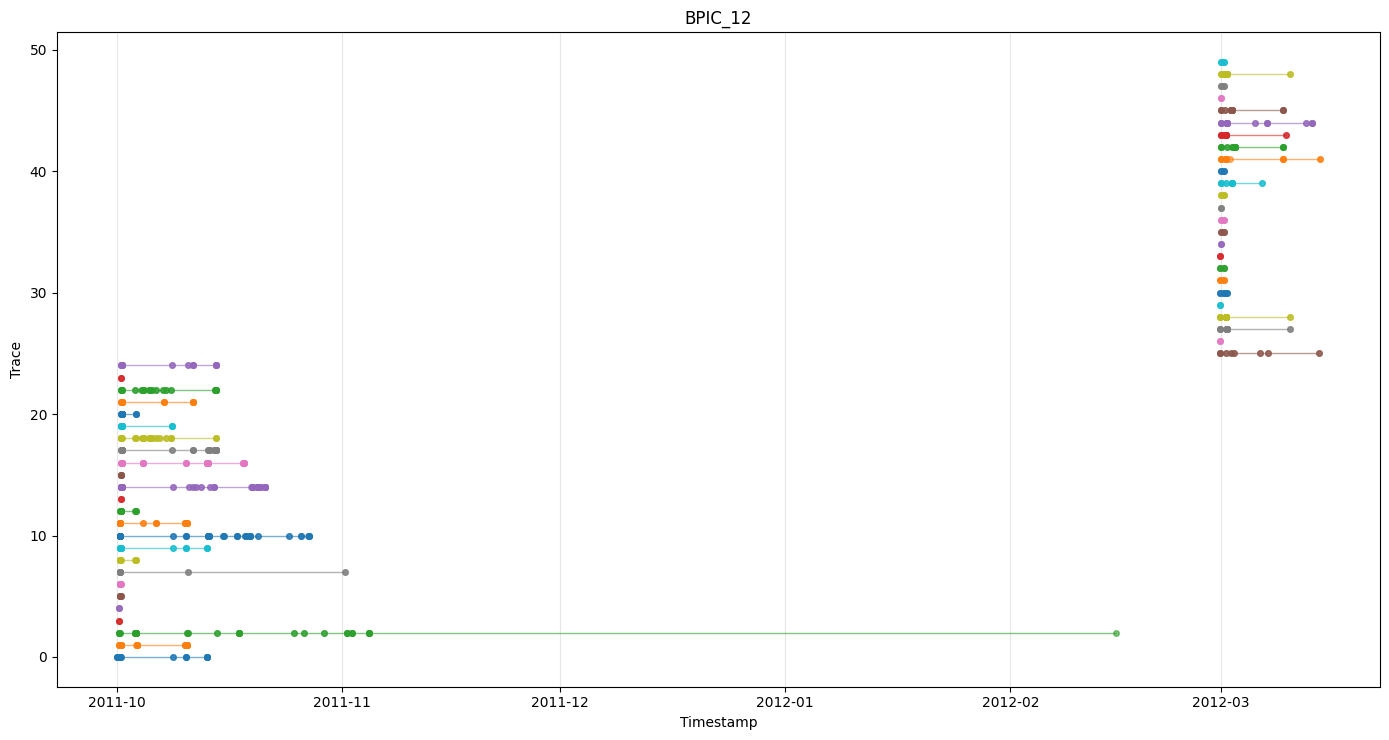

parsing log, completed traces :: 100%|██████████| 13087/13087 [00:01<00:00, 9010.01it/s]


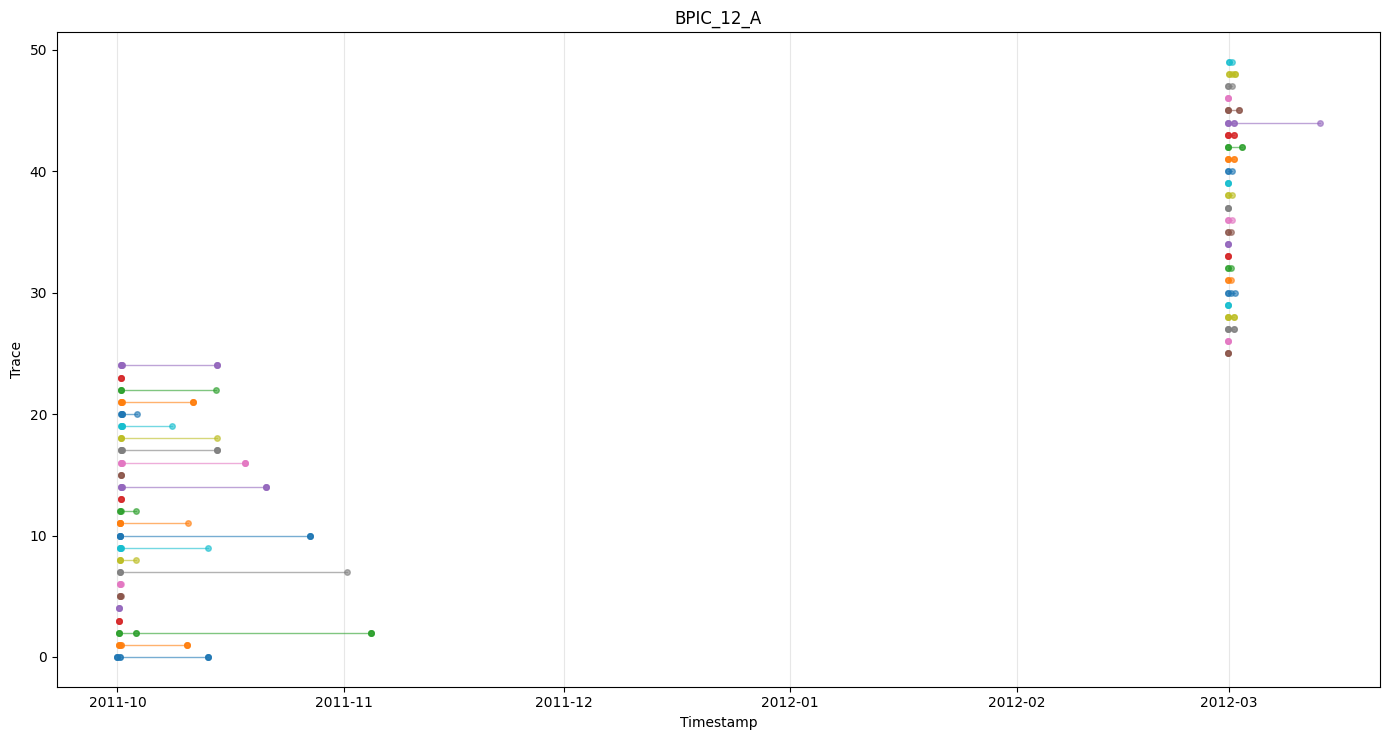

parsing log, completed traces :: 100%|██████████| 5015/5015 [00:00<00:00, 5151.58it/s]


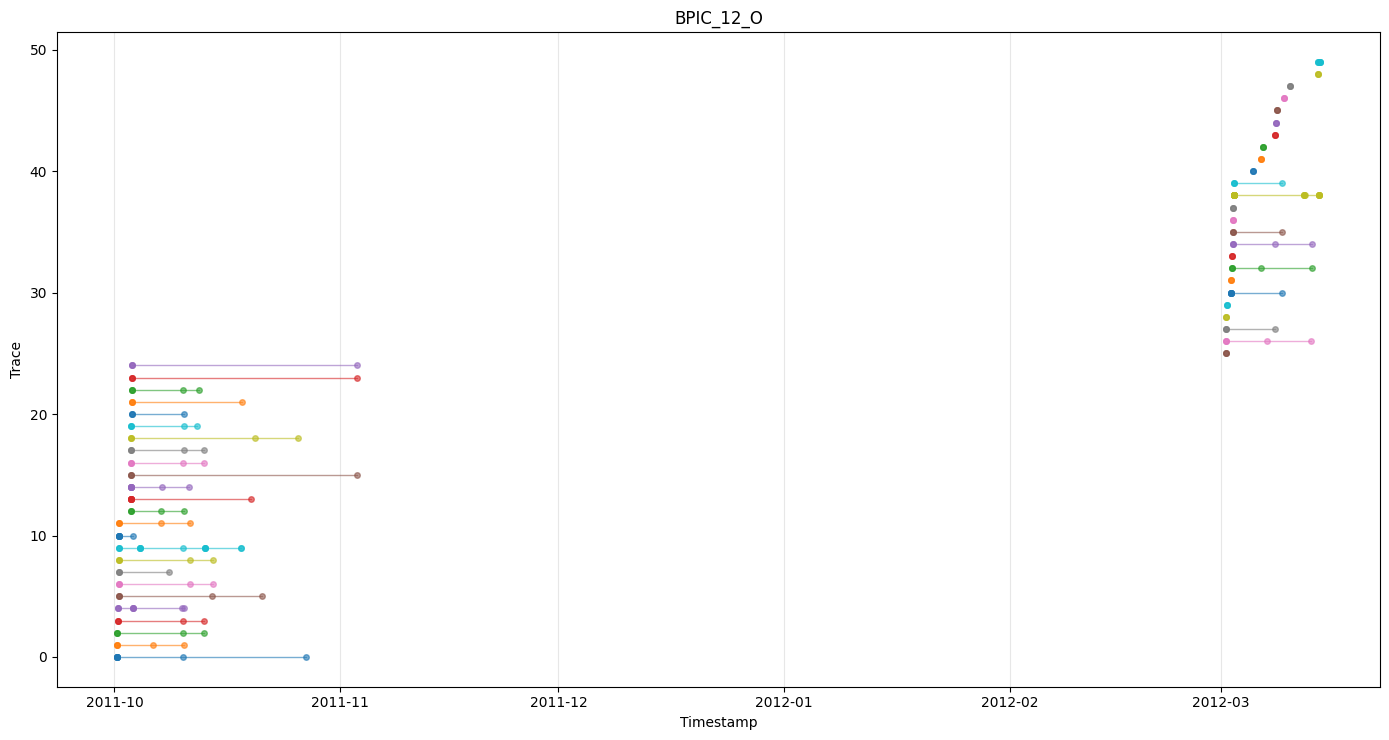

parsing log, completed traces :: 100%|██████████| 9658/9658 [00:04<00:00, 2262.90it/s]


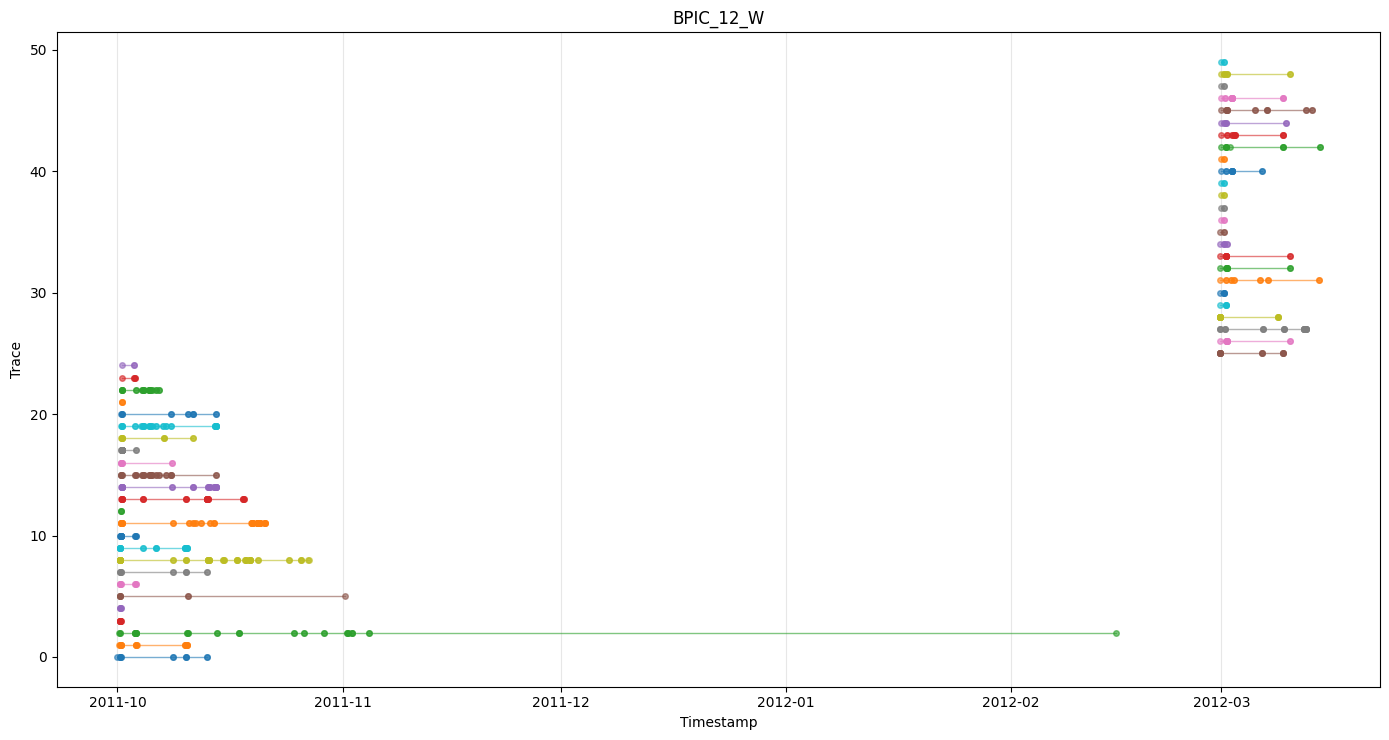

parsing log, completed traces :: 100%|██████████| 1487/1487 [00:00<00:00, 4233.22it/s]


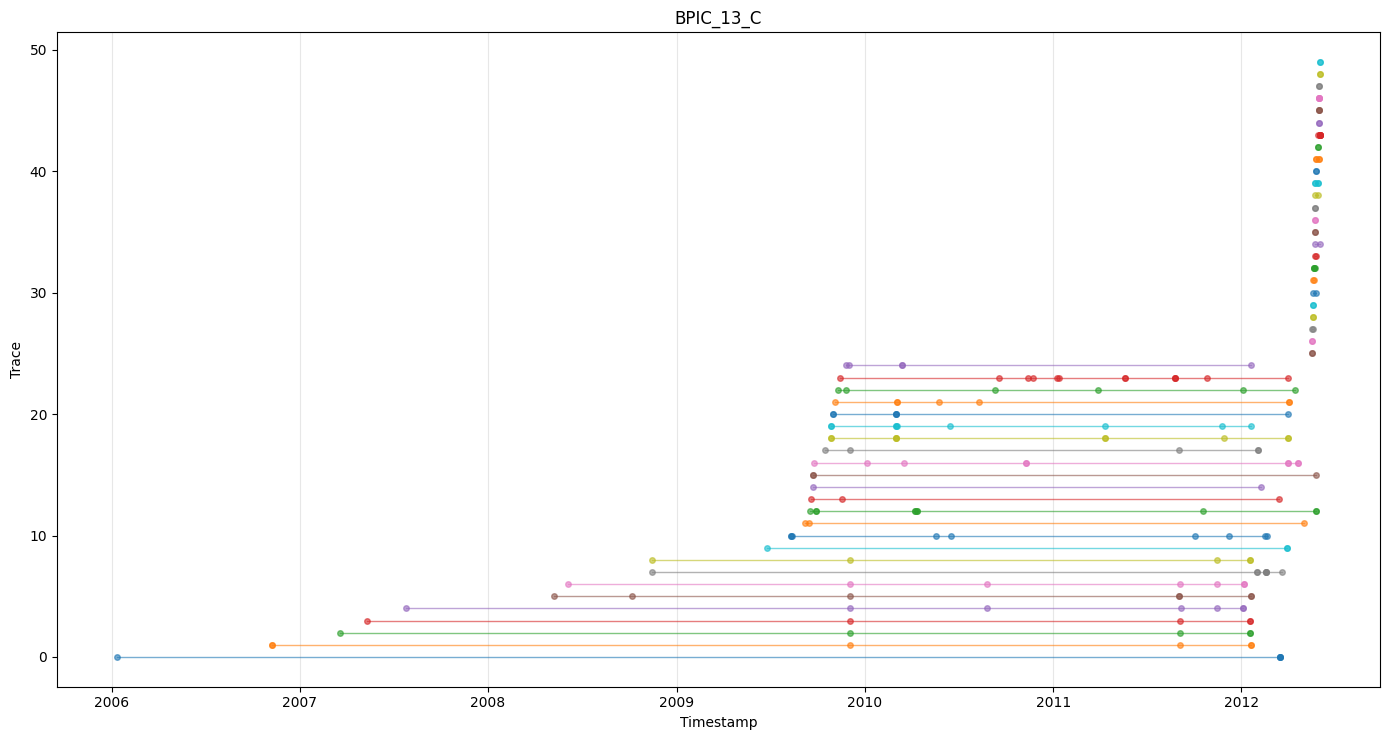

parsing log, completed traces :: 100%|██████████| 7554/7554 [00:03<00:00, 2212.58it/s]


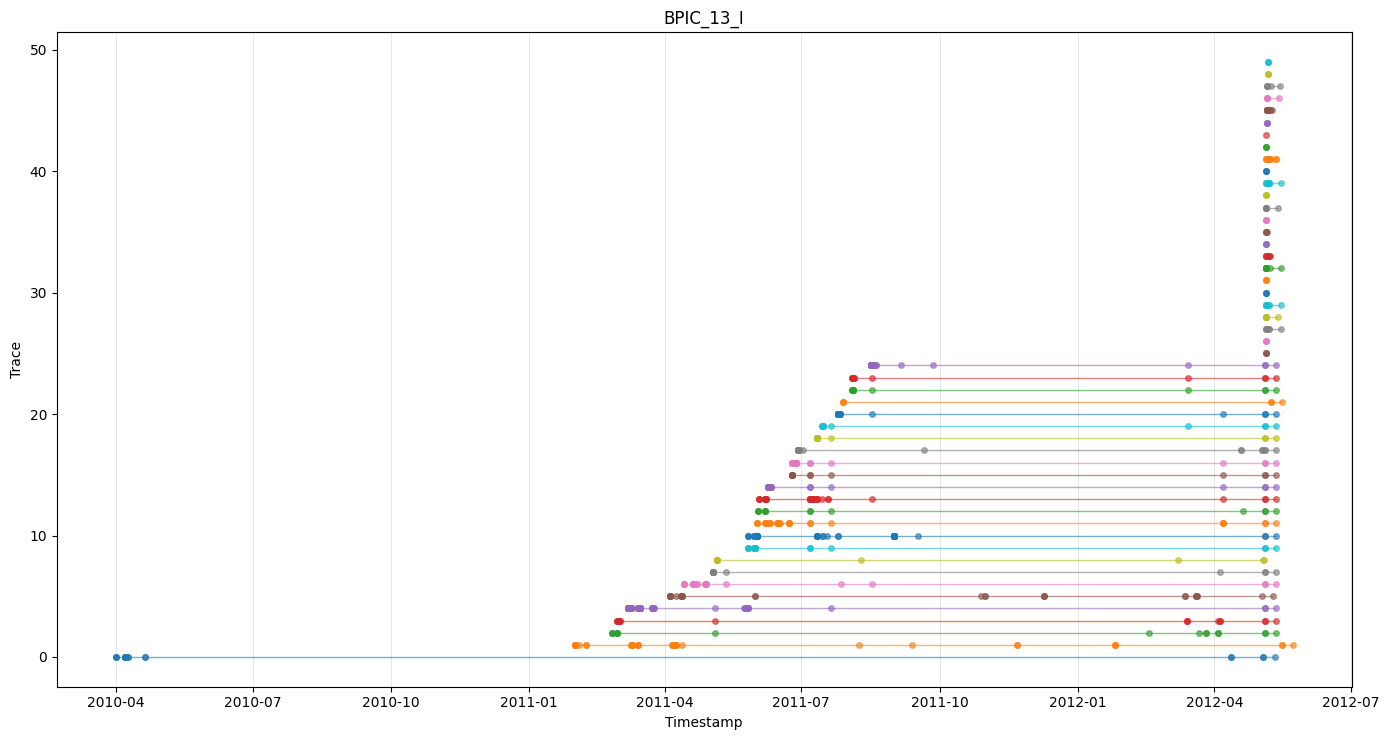

parsing log, completed traces :: 100%|██████████| 1199/1199 [00:02<00:00, 414.56it/s]


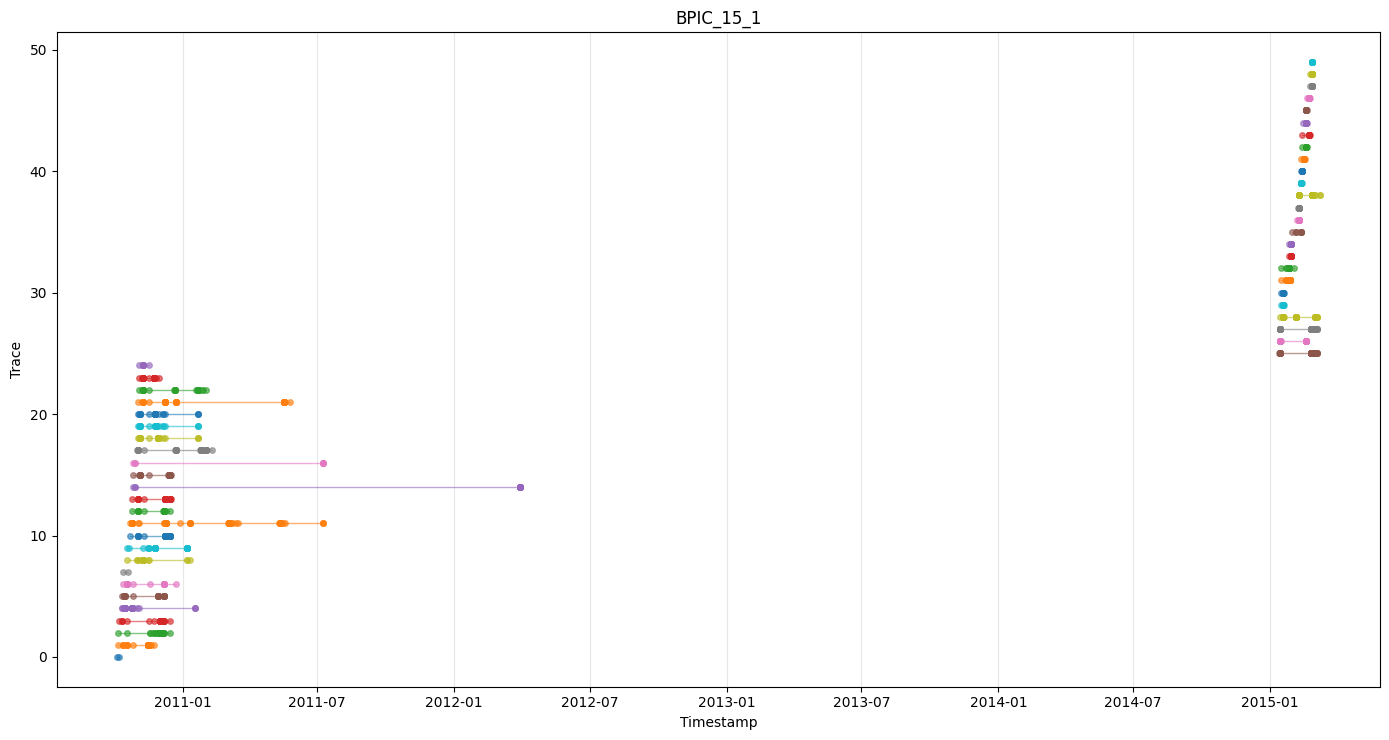

parsing log, completed traces :: 100%|██████████| 832/832 [00:02<00:00, 381.42it/s]


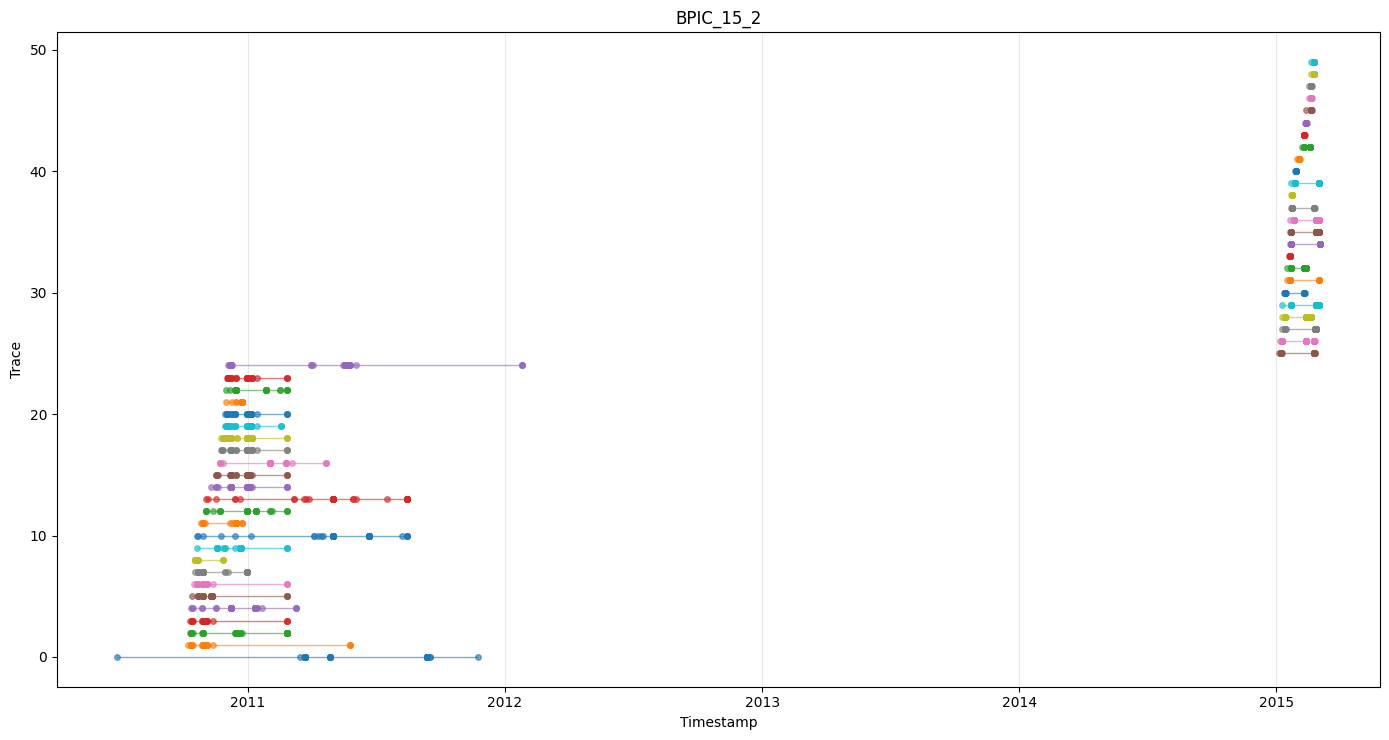

parsing log, completed traces :: 100%|██████████| 1409/1409 [00:03<00:00, 435.09it/s]


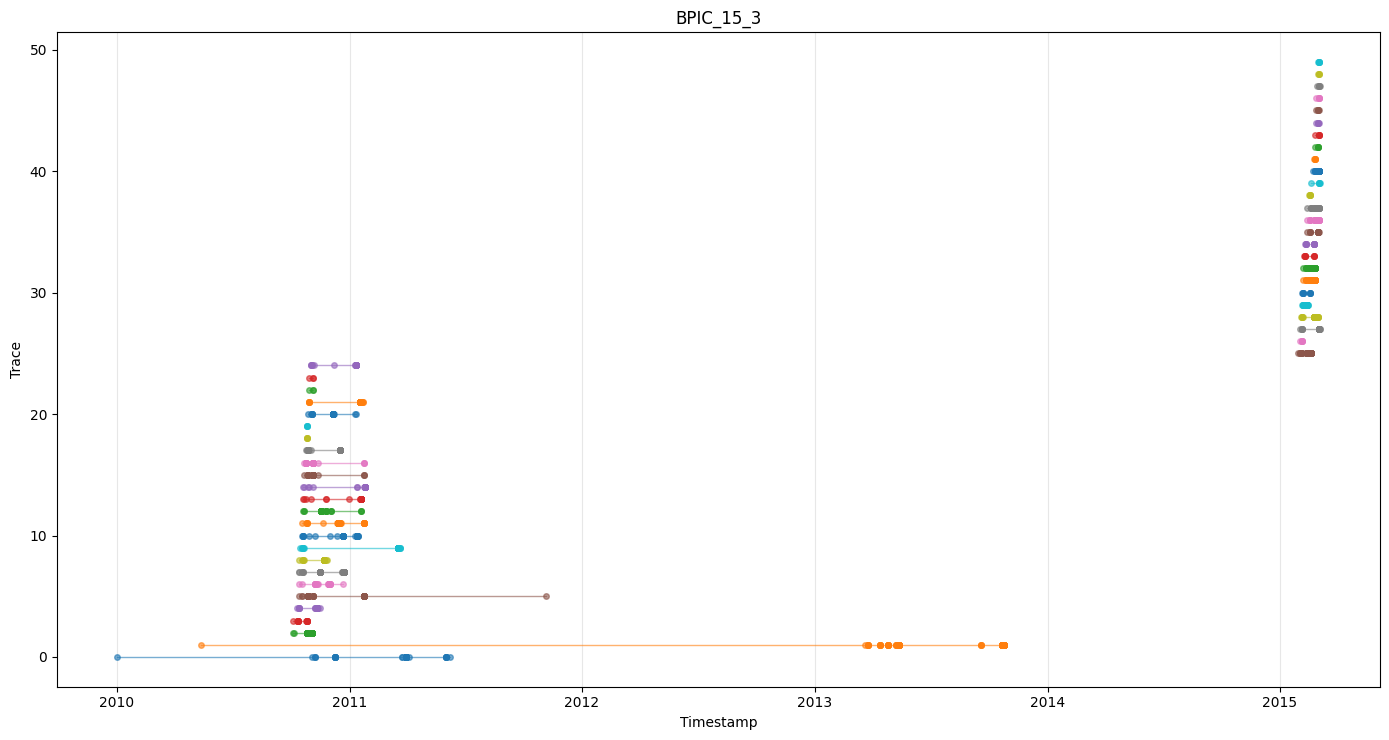

parsing log, completed traces :: 100%|██████████| 1053/1053 [00:02<00:00, 438.78it/s]


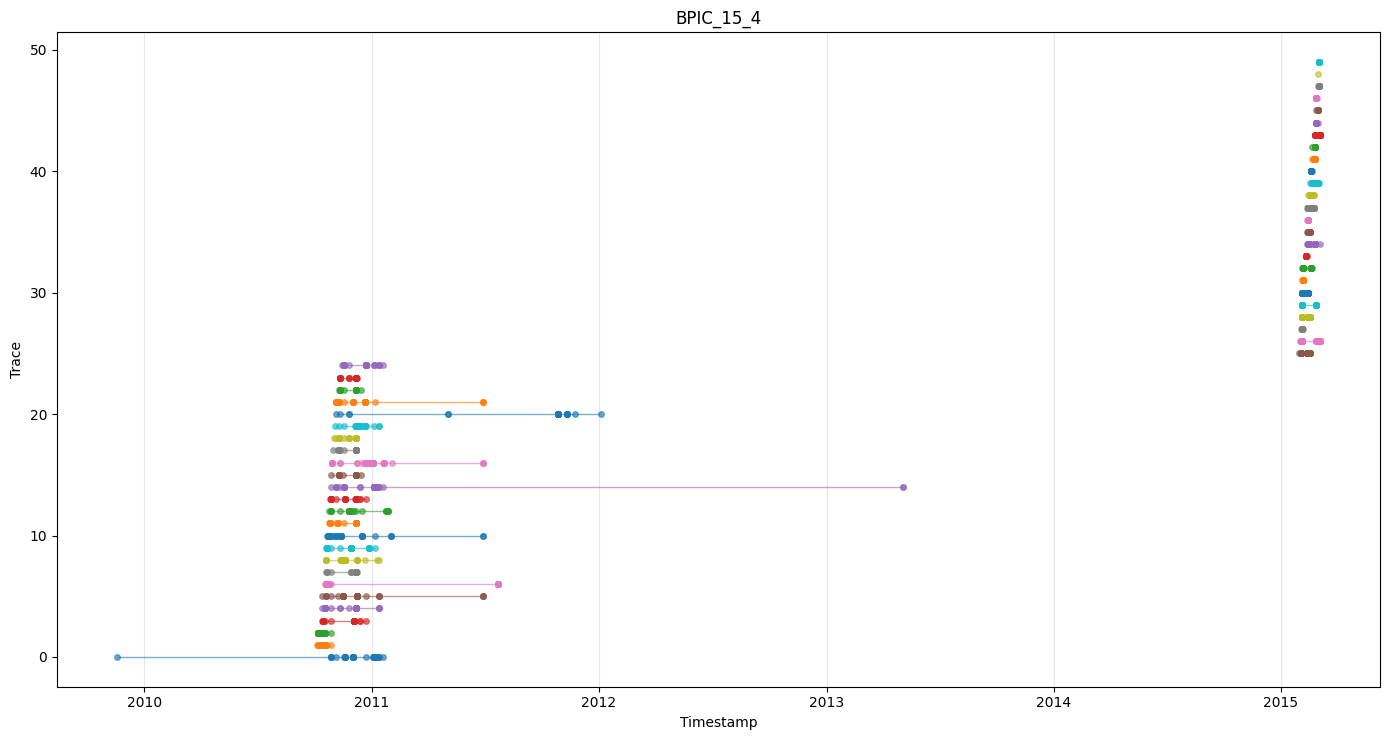

parsing log, completed traces :: 100%|██████████| 1156/1156 [00:03<00:00, 360.49it/s]


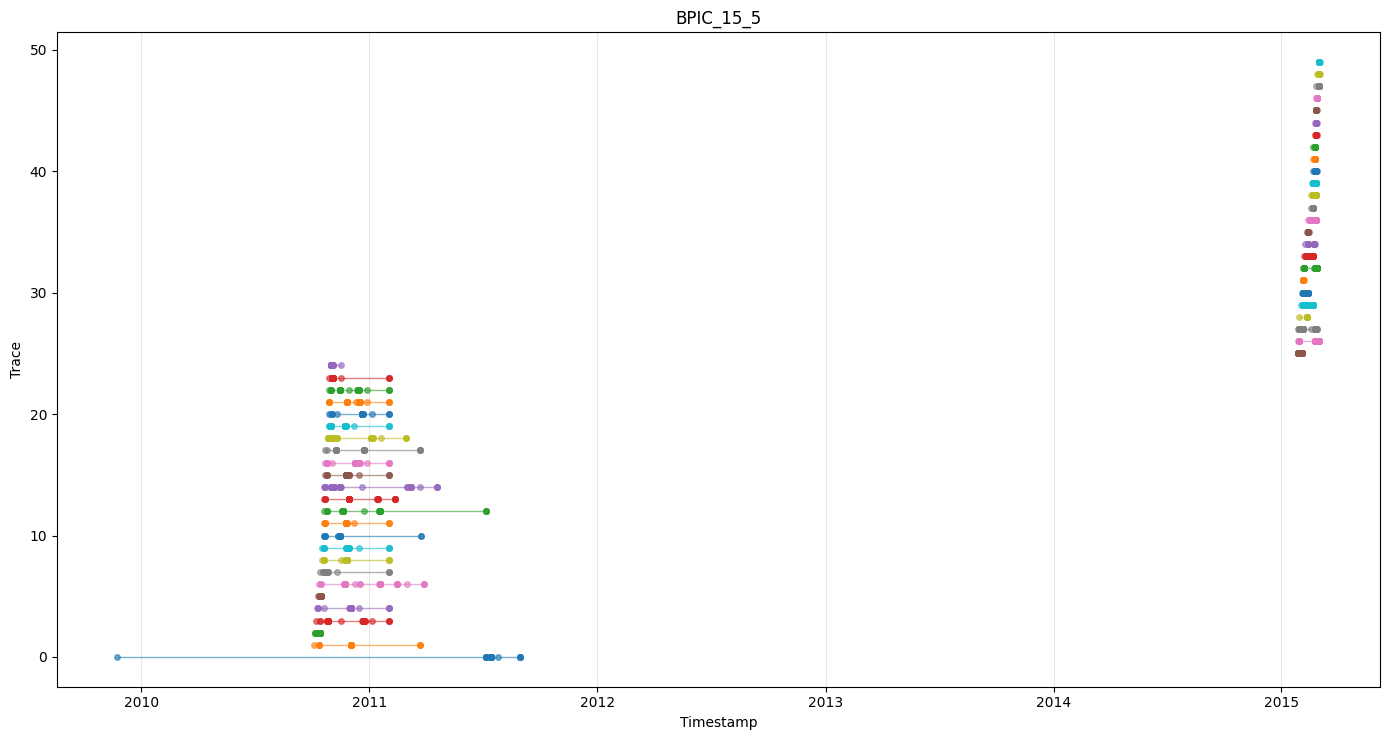

parsing log, completed traces :: 100%|██████████| 10500/10500 [00:01<00:00, 6498.12it/s]


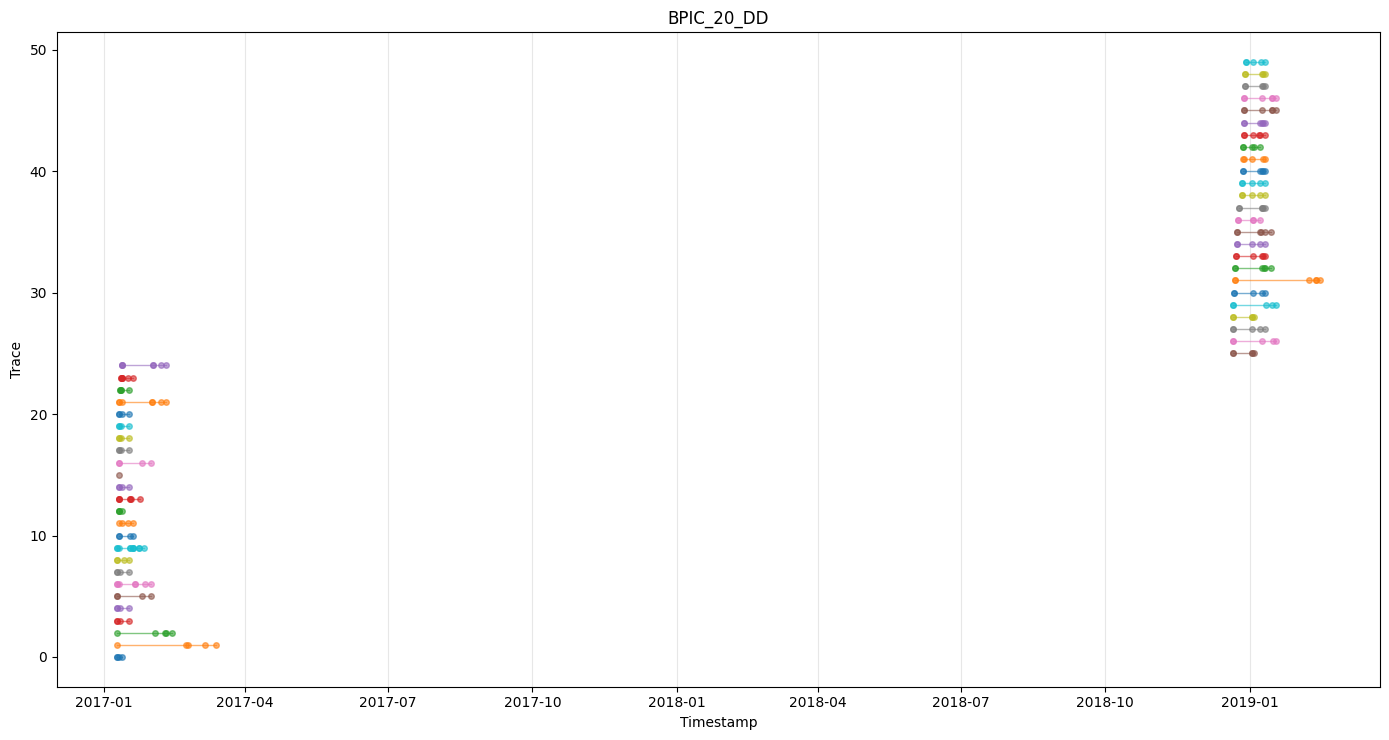

parsing log, completed traces :: 100%|██████████| 6449/6449 [00:02<00:00, 3101.83it/s]


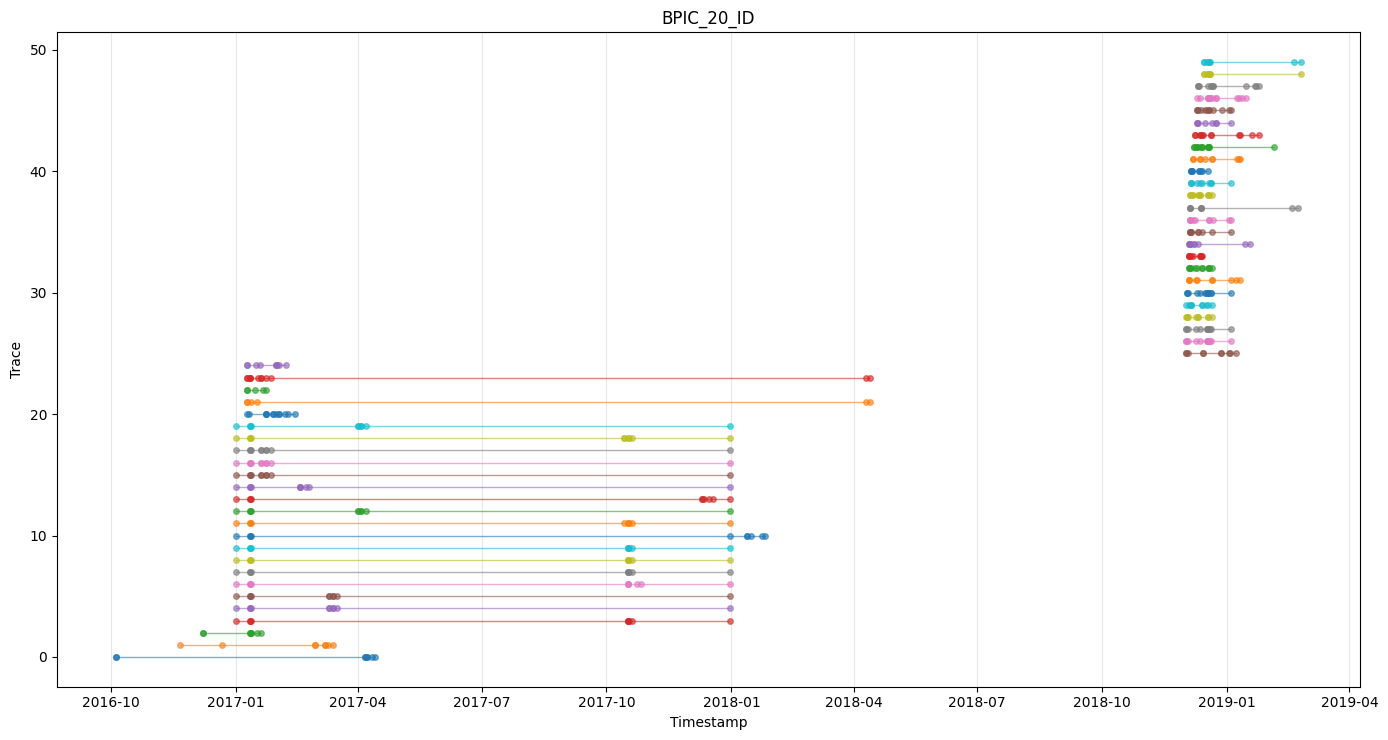

parsing log, completed traces :: 100%|██████████| 2099/2099 [00:00<00:00, 2812.61it/s]


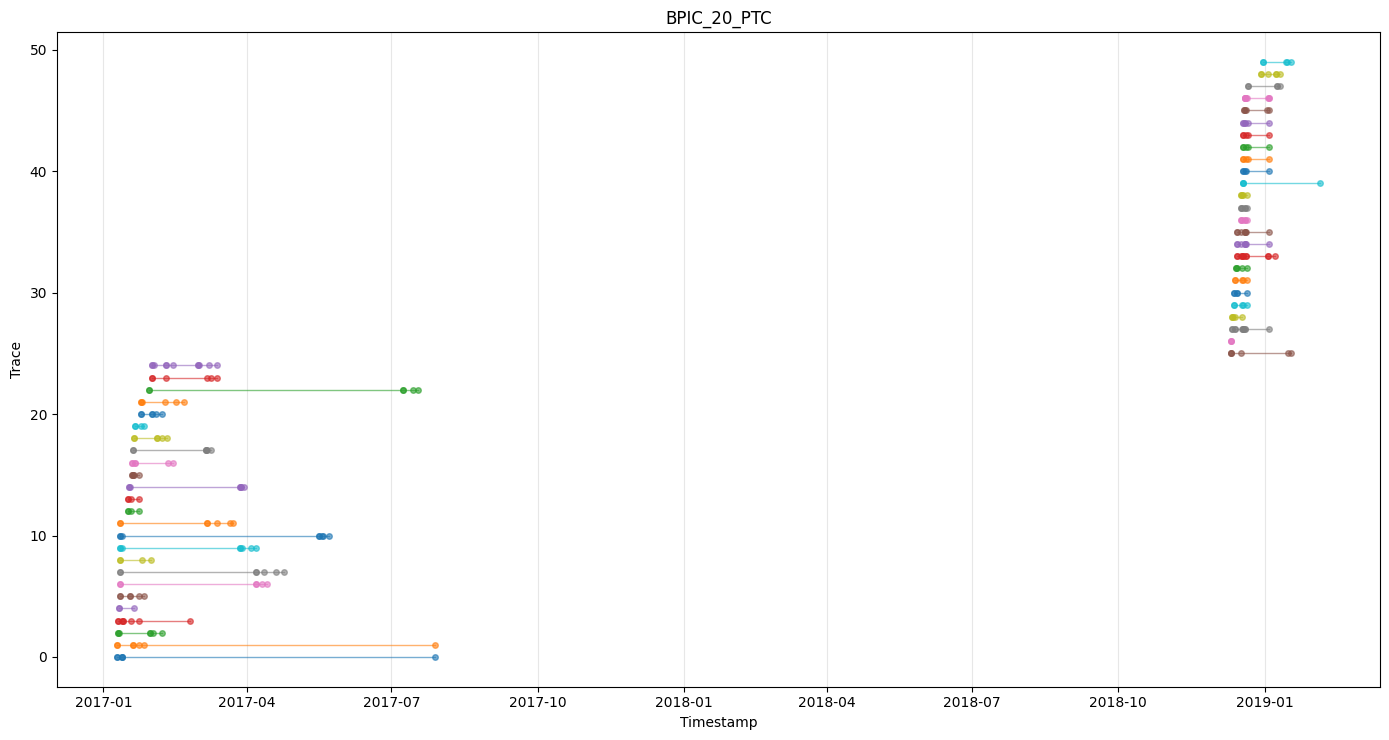

parsing log, completed traces :: 100%|██████████| 6886/6886 [00:00<00:00, 7337.05it/s]


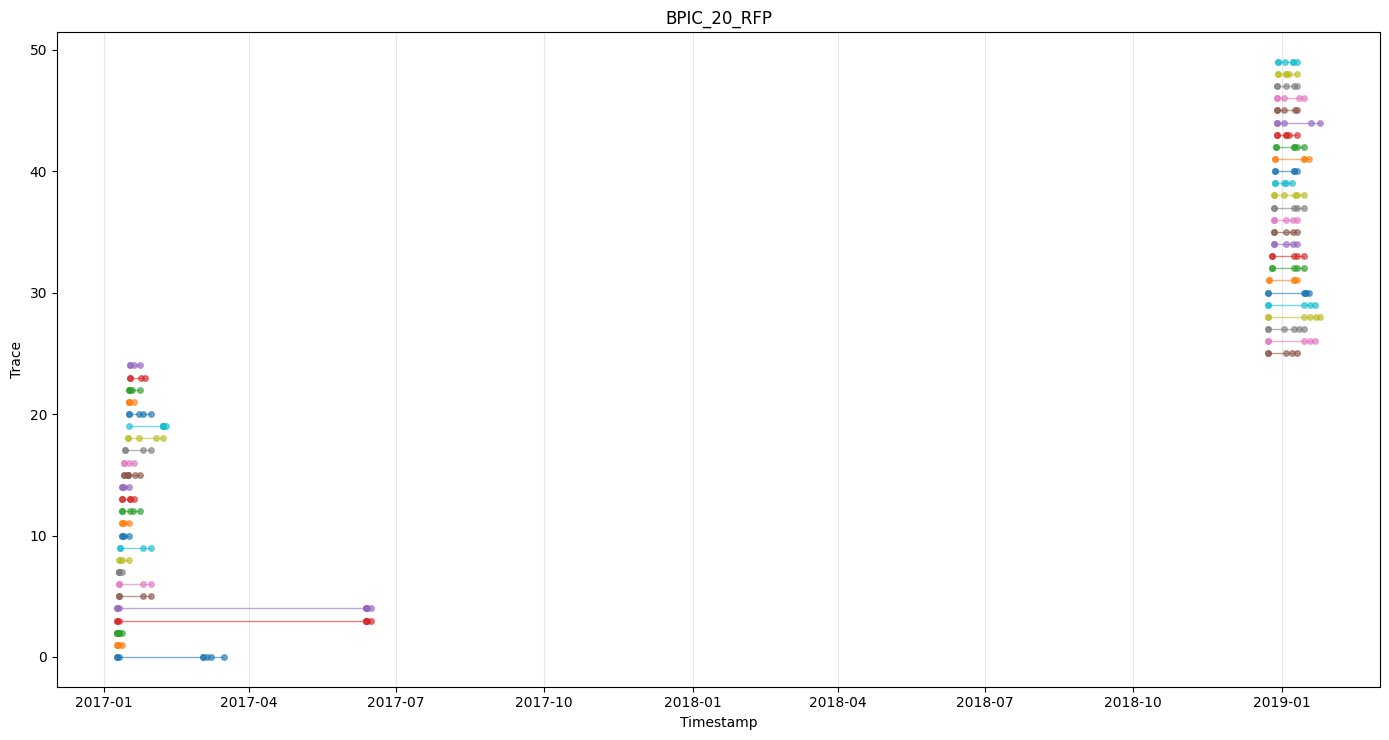

parsing log, completed traces :: 100%|██████████| 7065/7065 [00:02<00:00, 2723.63it/s]


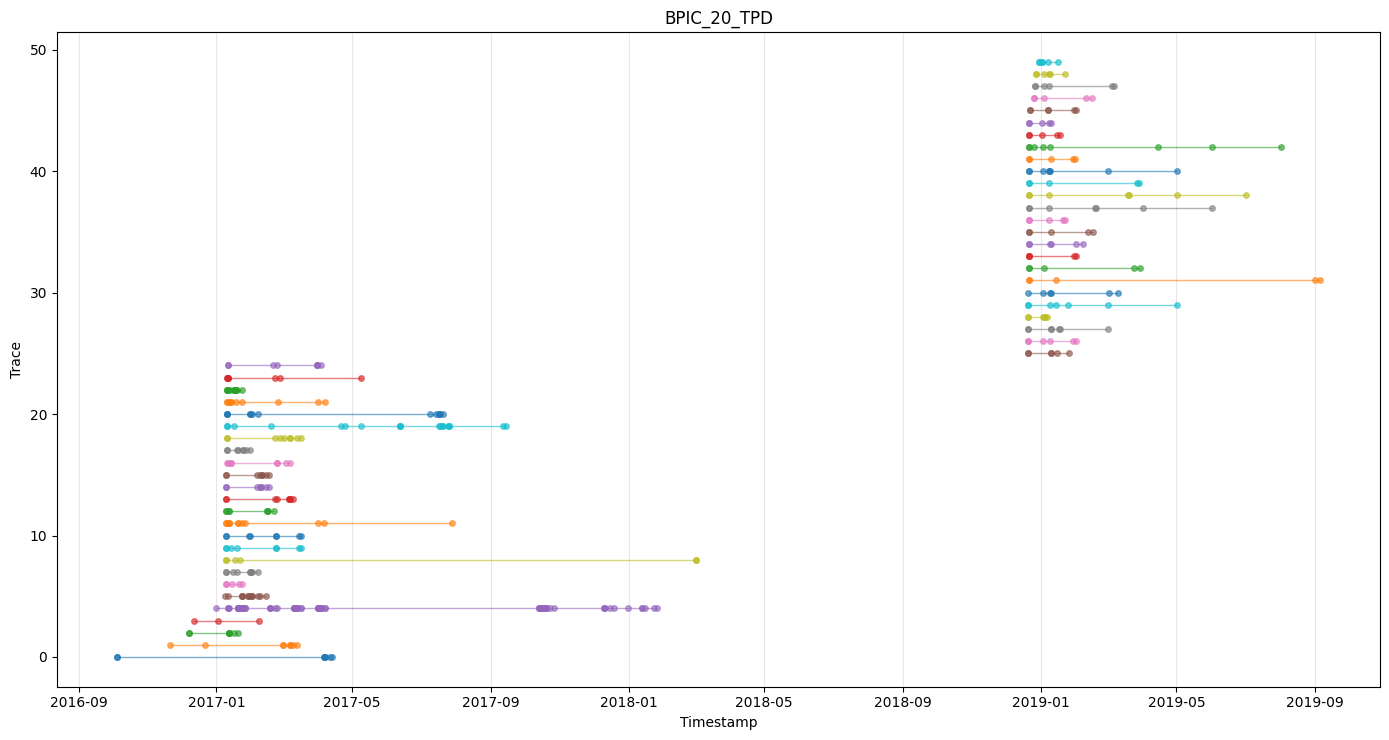

parsing log, completed traces :: 100%|██████████| 4580/4580 [00:02<00:00, 2143.09it/s]


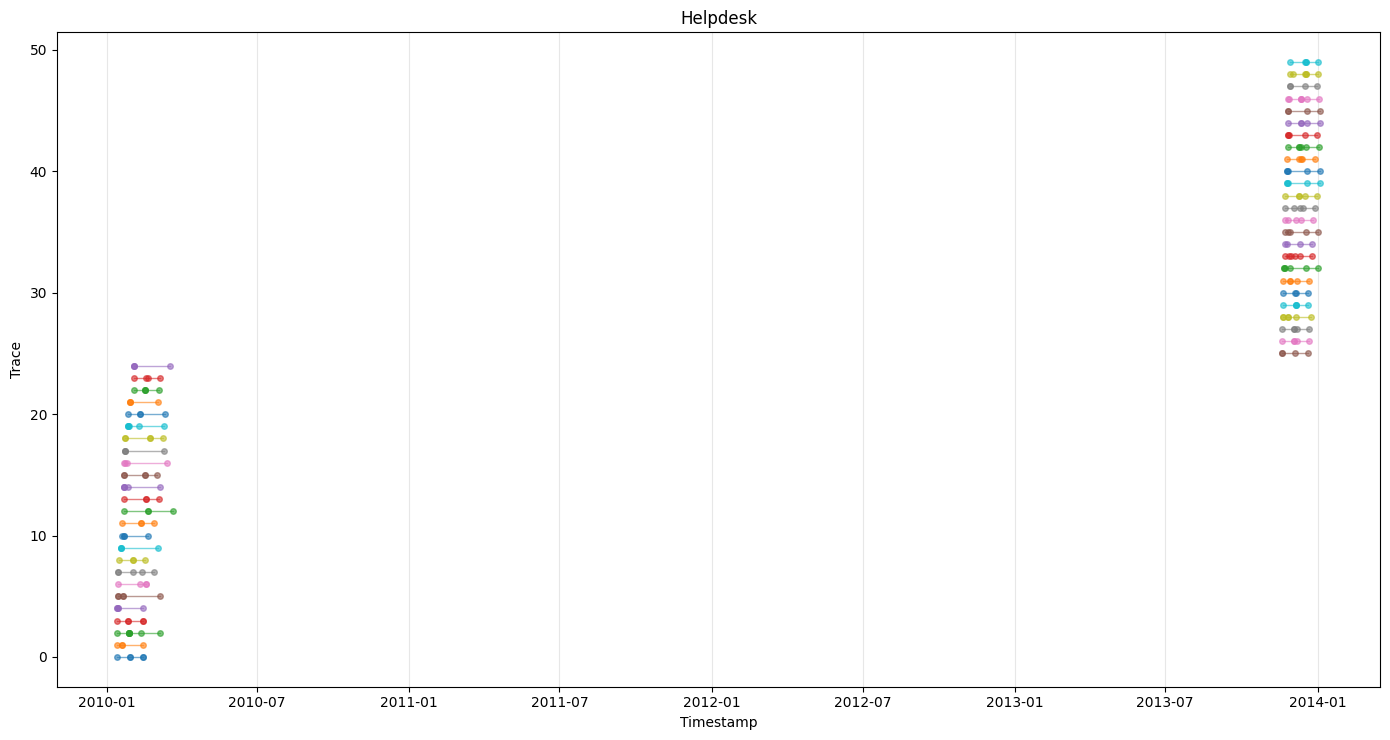

parsing log, completed traces :: 100%|██████████| 100000/100000 [00:16<00:00, 6035.97it/s]


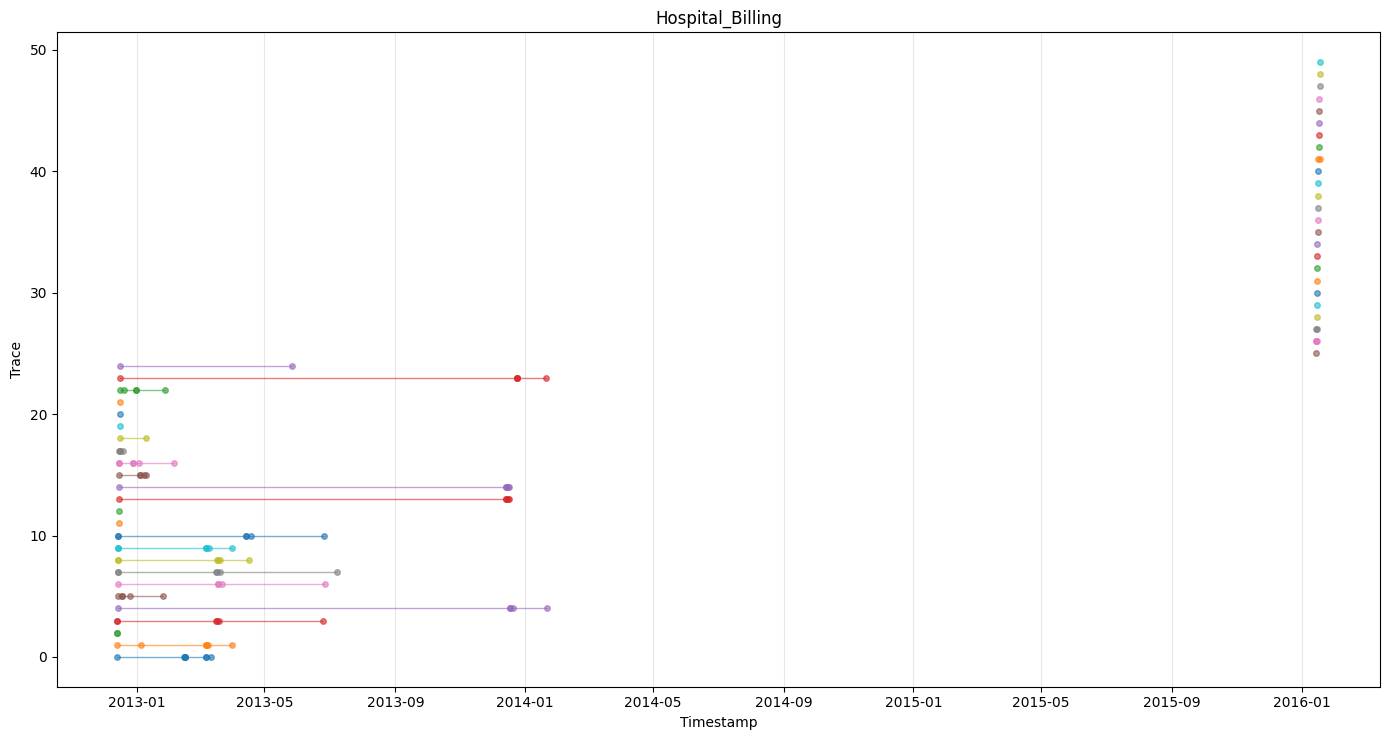

parsing log, completed traces :: 100%|██████████| 1050/1050 [00:00<00:00, 2669.79it/s]


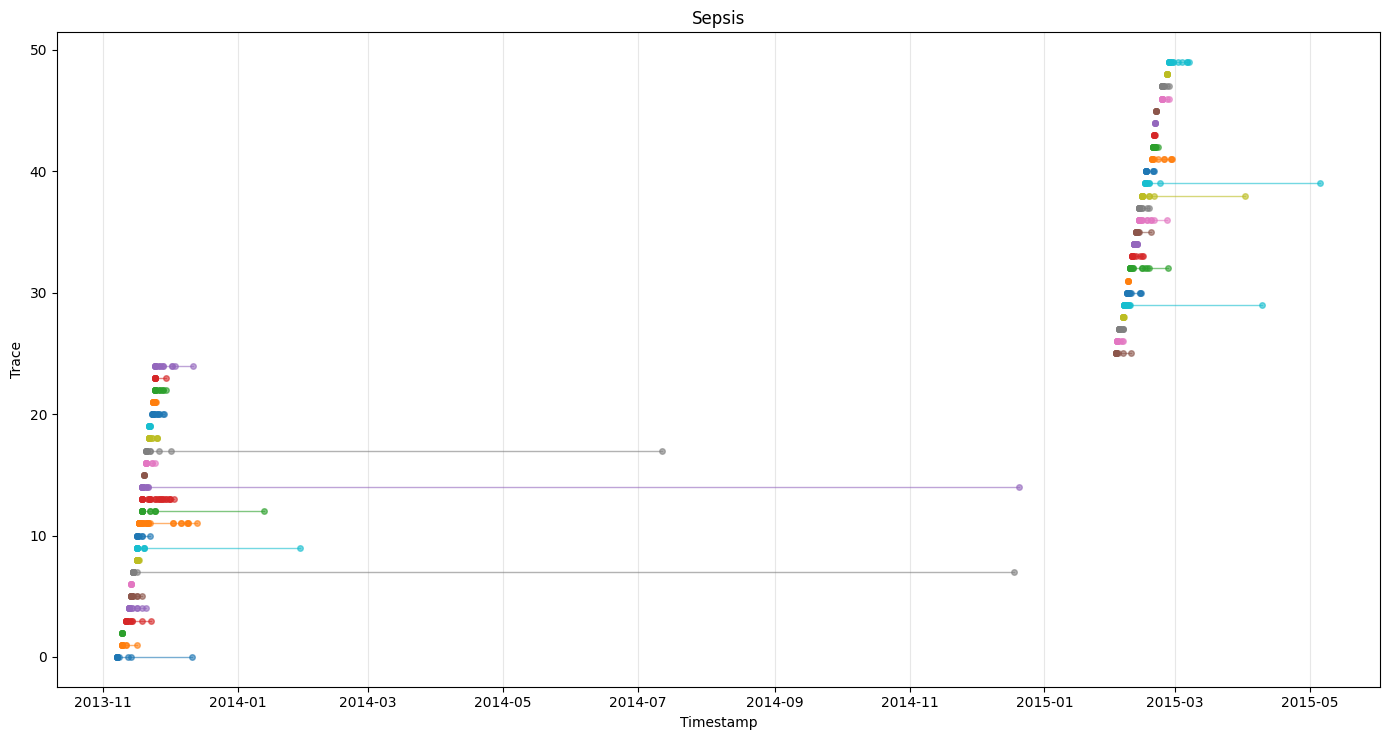

parsing log, completed traces :: 100%|██████████| 150370/150370 [00:17<00:00, 8382.79it/s] 


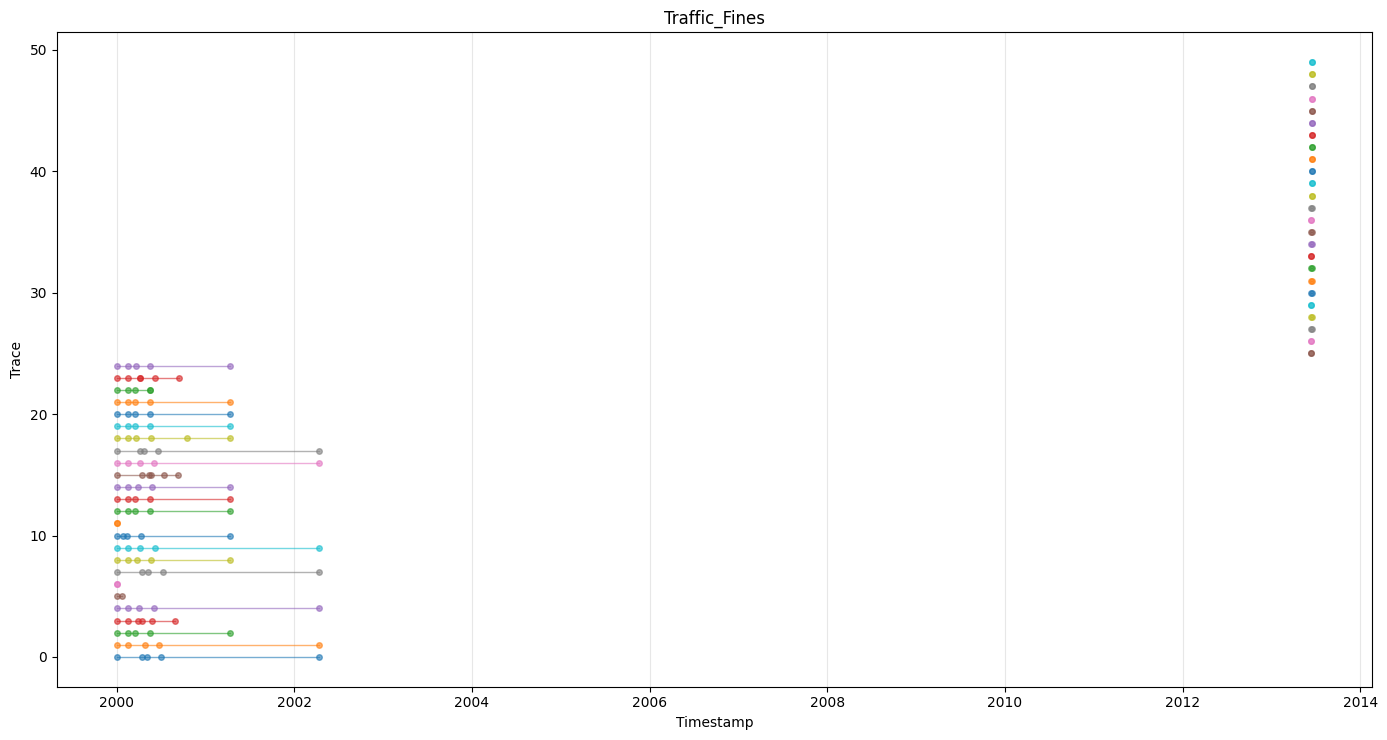

In [167]:
for dataset_name in DATASET_LIST:
    log, log_df = load_log(dataset_name)

    visualize_traces(log_df, dataset_name, first_traces=25, last_traces=25)

In [7]:
from utils.streaming.pybeamline import apply_censoring


def get_stream_size(
    log_df: pd.DataFrame,
    end_events: list[str],
    max_cases_rate: float = 0.1,
    init_cases_rate: float = 0.8,
    case_id_col: str = 'case:concept:name',
    activity_col: str = 'concept:name',
    time_col: str = 'time:timestamp',
):
    log_df = log_df.sort_values(by=[time_col])

    if end_events:
        log_df = apply_censoring(log_df, end_events, case_id_col, activity_col)

    log_df = log_df.reset_index(drop=True)

    total_events = len(log_df)
    total_cases = log_df[case_id_col].nunique()

    target_max_cases = math.ceil(total_cases * max_cases_rate)
    target_init_cases = math.floor(target_max_cases * init_cases_rate)

    # Chronological indices of case completions
    last_event_idx_per_case = log_df.groupby(case_id_col).tail(1).index.sort_values()

    max_idx = (
        last_event_idx_per_case[target_max_cases - 1] if target_max_cases > 0 else -1
    )
    init_idx = (
        last_event_idx_per_case[target_init_cases - 1] if target_init_cases > 0 else -1
    )

    max_events = max_idx + 1

    # Сases that have fully completed by init_idx
    completed_case_ids = log_df.loc[
        last_event_idx_per_case[:target_init_cases], case_id_col
    ]
    completed_events_count = len(log_df[log_df[case_id_col].isin(completed_case_ids)])
    init_size = completed_events_count - target_init_cases

    # Сases that complete during the evaluation phase
    eval_case_ids = log_df.loc[
        last_event_idx_per_case[target_init_cases:target_max_cases], case_id_col
    ]

    # Count events belonging to evaluation cases arrived after init phase
    eval_events_count = len(
        log_df[log_df[case_id_col].isin(eval_case_ids) & (log_df.index > init_idx)]
    )

    # Subtract the terminal event for each evaluation case
    predictions = eval_events_count - (target_max_cases - target_init_cases)

    return {
        'total_events': total_events,
        'total_cases': total_cases,
        'max_events': max_events,
        'init_size': init_size,
        'predictions': predictions,
    }

In [8]:
for dataset_name in DATASET_LIST:
    log, log_df = load_log(dataset_name)

    print(f'Dataset: {dataset_name}')

    end_events = END_EVENTS.get(dataset_name, [])

    hyperparam_search_size = get_stream_size(
        log_df, end_events, max_cases_rate=0.1, init_cases_rate=0.75
    )
    print(f'{hyperparam_search_size}')
    print('================================')


parsing log, completed traces :: 100%|██████████| 1487/1487 [00:00<00:00, 4168.91it/s]


Dataset: BPIC_13_C
{'total_events': 6660, 'total_cases': 1487, 'max_events': 3085, 'init_size': 311, 'predictions': 25}


parsing log, completed traces :: 100%|██████████| 7554/7554 [00:03<00:00, 2396.23it/s]


Dataset: BPIC_13_I
{'total_events': 65533, 'total_cases': 7554, 'max_events': 34047, 'init_size': 1851, 'predictions': 375}


parsing log, completed traces :: 100%|██████████| 10500/10500 [00:01<00:00, 5877.85it/s]


...

Dataset: Helpdesk
{'total_events': 21232, 'total_cases': 4557, 'max_events': 2559, 'init_size': 1358, 'predictions': 173}


parsing log, completed traces :: 100%|██████████| 100000/100000 [00:16<00:00, 6133.74it/s]


Dataset: Hospital_Billing
{'total_events': 403622, 'total_cases': 85905, 'max_events': 62257, 'init_size': 13686, 'predictions': 392}


parsing log, completed traces :: 100%|██████████| 150370/150370 [00:18<00:00, 7996.78it/s] 


Dataset: Traffic_Fines
{'total_events': 533532, 'total_cases': 144025, 'max_events': 103460, 'init_size': 21325, 'predictions': 227}


In [9]:
for dataset_name in DATASET_LIST:
    log, log_df = load_log(dataset_name)

    print(f'Dataset: {dataset_name}')

    end_events = END_EVENTS.get(dataset_name, [])

    hyperparam_search_size = get_stream_size(
        log_df, end_events, max_cases_rate=1.0, init_cases_rate=0.1
    )
    print(f'{hyperparam_search_size}')
    print('================================')


parsing log, completed traces :: 100%|██████████| 1487/1487 [00:00<00:00, 4356.20it/s]


Dataset: BPIC_13_C
{'total_events': 6660, 'total_cases': 1487, 'max_events': 6660, 'init_size': 438, 'predictions': 2243}


parsing log, completed traces :: 100%|██████████| 7554/7554 [00:03<00:00, 2103.40it/s]


Dataset: BPIC_13_I
{'total_events': 65533, 'total_cases': 7554, 'max_events': 65533, 'init_size': 2326, 'predictions': 24697}


parsing log, completed traces :: 100%|██████████| 10500/10500 [00:01<00:00, 6024.00it/s]


...

Dataset: Helpdesk
{'total_events': 21232, 'total_cases': 4557, 'max_events': 21232, 'init_size': 1819, 'predictions': 14572}


parsing log, completed traces :: 100%|██████████| 100000/100000 [00:15<00:00, 6270.11it/s]


Dataset: Hospital_Billing
{'total_events': 403622, 'total_cases': 85905, 'max_events': 403622, 'init_size': 23352, 'predictions': 264052}


parsing log, completed traces :: 100%|██████████| 150370/150370 [00:18<00:00, 8146.28it/s] 


Dataset: Traffic_Fines
{'total_events': 533532, 'total_cases': 144025, 'max_events': 533532, 'init_size': 35362, 'predictions': 300450}
